[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 concepts.

* Using [chat messages](https://docs.langchain.com/oss/python/langchain/messages) as our graph state
* Using [chat models](https://docs.langchain.com/oss/python/integrations/chat) in graph nodes
* [Binding tools](https://docs.langchain.com/oss/python/langchain/models#tool-calling) to our chat model
* [Executing tool calls](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

## Messages

Chat models can use [messages](https://docs.langchain.com/oss/python/langchain/messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models

Chat models use a sequence of messages as input and support message types, as discussed above.

There are [many](https://docs.langchain.com/oss/python/integrations/chat) to choose from! Let's work with OpenAI. 

Let's check that your `OPENAI_API_KEY` is set and, if not, you will be asked to enter it.

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPEROUTER_API_KEY")

We can load a chat model and invoke it with out list of messages.

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [9]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
import os

API = os.getenv("OPENROUTER_API_KEY")
MODEL = "nvidia/nemotron-3-nano-30b-a3b:free"
URL = "https://openrouter.ai/api/v1/"

llm = ChatOpenAI(model=MODEL, api_key=API, base_url=URL)

result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [10]:
result

AIMessage(content='### Top U.S.Destinations for Watching Orcas (Killer Whales)\n\n| Region / Location | Why It’s Great for Orcas | Best Time to See Them | How to See Them (Tours / Tips) |\n|-------------------|--------------------------|----------------------|--------------------------------|\n| **San Juan Islands, Washington** | **Resident & Transient pods** of Southern Resident (SRKW) and a handful of Transient (Bigg’s) orcas regularly visit the inland waters of the islands (especially Haro Strait, Lime Kiln Bay). | **Late spring through early fall** (May‑Oct), with peak sightings from July‑Sept when salmon runs are strong. | • Book a **whale‑watching charter** from Friday Harbor or Anacortes.<br>• Join a **guided “Orca Watch” boat** (most run 3–5\u202fhr trips).<br>• Land‑based spots: **Lime Kiln Point State Park** (“Whale Watch Park”) – excellent for spotting seals and orcas without leaving shore. |\n| **Monterey Bay, California** | The **“Killer Whale Capital of the West Coast.”**

In [11]:
result.response_metadata

{'token_usage': {'completion_tokens': 1670,
  'prompt_tokens': 79,
  'total_tokens': 1749,
  'completion_tokens_details': {'accepted_prediction_tokens': None,
   'audio_tokens': 0,
   'reasoning_tokens': 94,
   'rejected_prediction_tokens': None,
   'image_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0,
   'cached_tokens': 0,
   'cache_write_tokens': 0,
   'video_tokens': 0},
  'cost': 0,
  'is_byok': False,
  'cost_details': {'upstream_inference_cost': 0,
   'upstream_inference_prompt_cost': 0,
   'upstream_inference_completions_cost': 0}},
 'model_provider': 'openai',
 'model_name': 'nvidia/nemotron-3-nano-30b-a3b:free',
 'system_fingerprint': None,
 'id': 'gen-1775812964-5vaQFnAWLbzVUsQgQDoL',
 'finish_reason': 'stop',
 'logprobs': None}

## Tools
> #### for attaching our user defined tools/functions with the model 
Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://docs.langchain.com/oss/python/integrations/chat) and [tool calling interface](https://blog.langchain.com/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [ ]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [13]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [14]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_6f80c252e3b64c9fbce2421b',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use  [messages](https://docs.langchain.com/oss/python/langchain/overview#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [16]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## **Reducers**


### The Problem

When a node in your graph runs, it returns new state. By default, LangGraph **replaces** the old value entirely.

```
Before: messages = [msg1, msg2]
Node returns: [msg3]
After (default): messages = [msg3]  ← msg1 and msg2 are GONE! ❌
```

You want to **keep** the old messages and add new ones.

### The Solution: [Reducers](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers)

A **reducer** is just a function that says *"here's how to combine old value + new value"*

```
Before: messages = [msg1, msg2]
Node returns: [msg3]
After (with add_messages reducer): messages = [msg1, msg2, msg3]  ← All kept! ✓
```

### How `Annotated` Connects to This

```python
messages: Annotated[list[AnyMessage], add_messages]
#        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
#        "This is a list, AND use add_messages to update it"
```

| Part | What it does |
|------|-------------|
| `list[AnyMessage]` | Type checking - "this should be a list of messages" |
| `add_messages` | Runtime behavior - "append new messages, don't replace" |

### Visual Example

```python
# Node 1 runs
return {"messages": [HumanMessage("Hello")]}

# State becomes: [Hello]

# Node 2 runs  
return {"messages": [AIMessage("Hi there!")]}

# Without reducer: [Hi there!]  ← replaced!
# With add_messages: [Hello, Hi there!]  ← appended!
```

### In Short

`Annotated[type, reducer]` = **"This field has this type, AND here's how to update it"**

The `add_messages` reducer is just a helper that does `old_list + new_list` instead of `new_list`.

In [17]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built  [`MessagesState`](https://docs.langchain.com/oss/python/langgraph/graph-api#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [18]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [19]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='d6ef7289-825a-4402-a144-d03ca3e85107', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='364c4706-94e2-485b-97af-151d7c02ad94'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='19ae3abe-82f8-4311-b996-3faf047e840c', tool_calls=[], invalid_tool_calls=[])]

## Our graph

Now, lets use `MessagesState` with a graph.

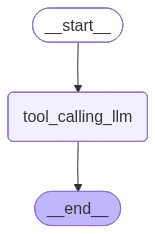

In [20]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [21]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today? Let me know if you have any questions or need help with anything! 😊


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [22]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 90909090 and 0")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 90909090 and 0
================================== Ai Message ==================================
Tool Calls:
  multiply (call_002a7665a1254e0384e1020b)
 Call ID: call_002a7665a1254e0384e1020b
  Args:
    b: 0
    a: 90909090
